# Homework 12

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import pygad

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, adjusted_rand_score

sns.set(style="whitegrid")
np.random.seed(42)
torch.manual_seed(42)

print("Бібліотеки імпортовано успішно.")

Бібліотеки імпортовано успішно.


## 1. Завантаження та підготовка даних
Завантажимо датасет, розділимо його на ознаки та цільову змінну, а також виконаємо стандартизацію.

In [40]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Розмірність даних: {df.shape}")
print(f"Класи: {target_names}")
print(f"Розподіл класів:\n{df['target'].value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Дані успішно підготовлено.")

Розмірність даних: (569, 31)
Класи: ['malignant' 'benign']
Розподіл класів:
target
1    357
0    212
Name: count, dtype: int64
Дані успішно підготовлено.


## 2. Візуалізація даних
Побудуємо pairplot декількох ознак

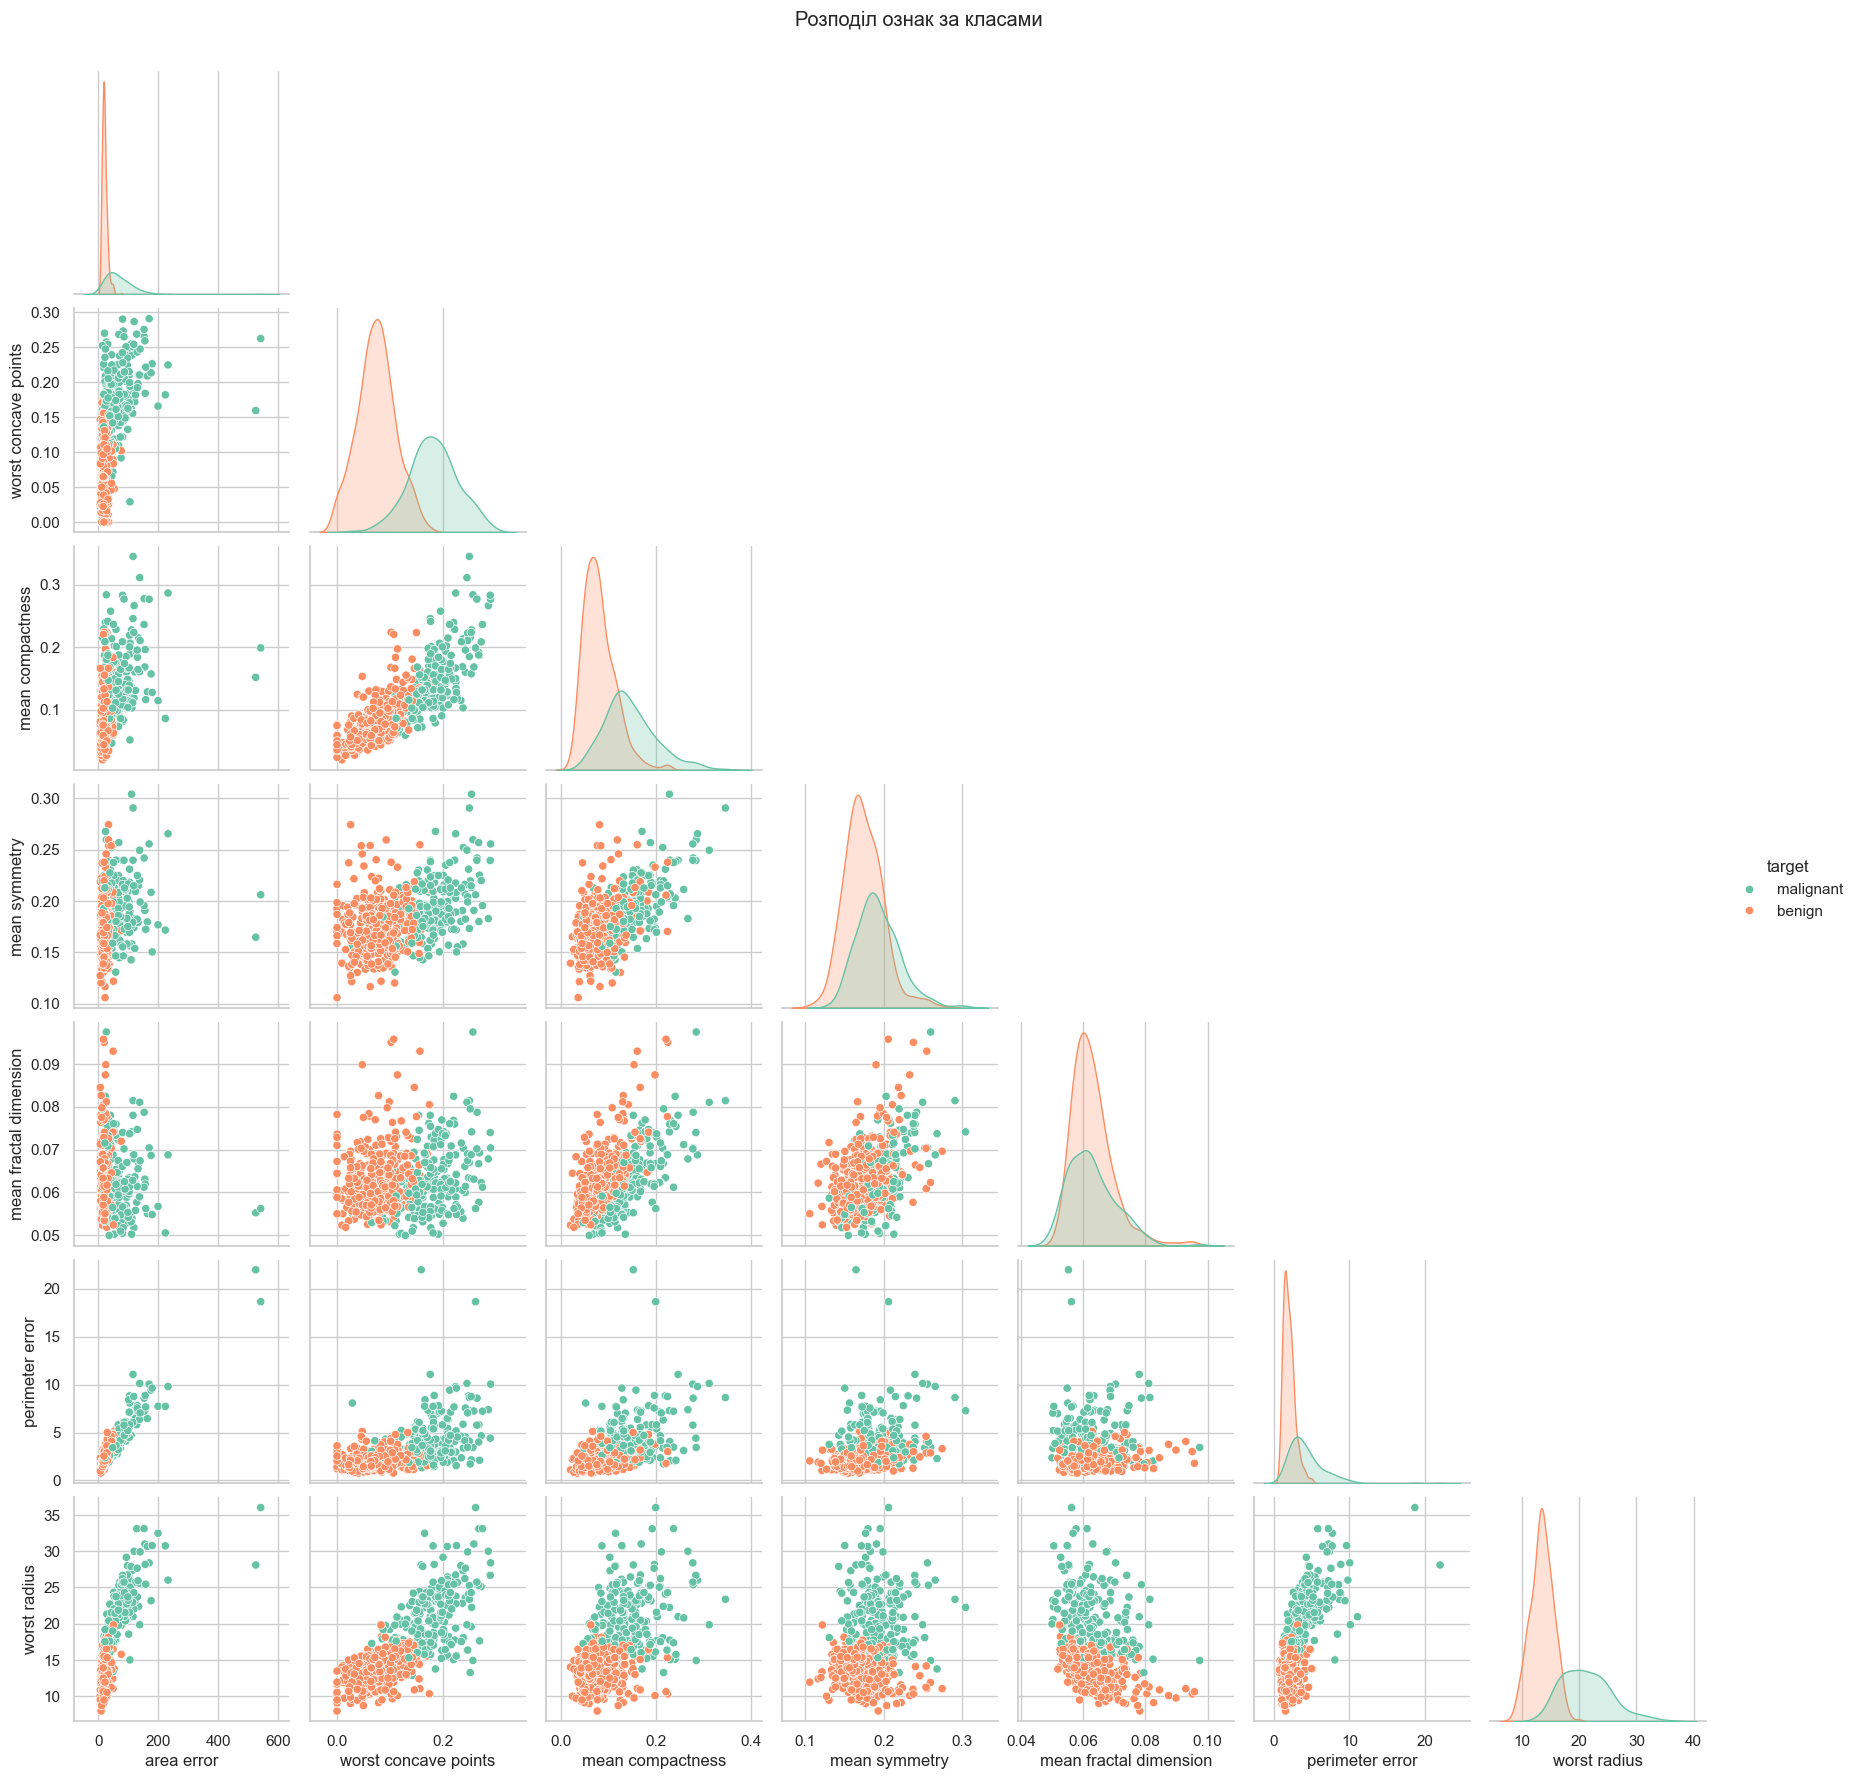

In [41]:
cols_to_plot = ['area error', 'worst concave points', 'mean compactness', 
                 'mean symmetry', 'mean fractal dimension', 'perimeter error', 
                 'worst radius']
subset_df = df[list(cols_to_plot) + ['target']].copy()
subset_df['target'] = subset_df['target'].map({0: 'malignant', 1: 'benign'})

sns.pairplot(subset_df, hue='target', palette='Set2', diag_kind='kde', corner=True)
plt.suptitle("Розподіл ознак за класами", y=1.02)
plt.show()

## 3. Кластерізація

Спробуємо знайти структуру в даних без учителя, використовуючи K-Means, Spectral Clustering та GMM. Оскільки ми знаємо, що класів 2, встановимо це як гіперпараметр.

In [42]:
# Оскільки кластеризація не знає справжніх міток (0 чи 1),
# ми використовуємо Adjusted Rand Index (ARI) для оцінки схожості з істинними мітками.
# ARI = 1.0 - ідеальний збіг, ARI ~ 0.0 - випадковий результат.

# 1. K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_scaled)
ari_kmeans = adjusted_rand_score(y_train, kmeans_labels)

# 2. Спектральна кластеризація
# Використовуємо меншу вибірку або affinity='nearest_neighbors' для швидкості та стабільності
spectral = SpectralClustering(n_clusters=2, random_state=42, affinity='nearest_neighbors', assign_labels='kmeans')
spectral_labels = spectral.fit_predict(X_train_scaled)
ari_spectral = adjusted_rand_score(y_train, spectral_labels)

# 3. Gaussian Mixture Models (GMM)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_train_scaled)
gmm_labels = gmm.predict(X_train_scaled)
ari_gmm = adjusted_rand_score(y_train, gmm_labels)

print(f"K-Means ARI: {ari_kmeans:.4f}")
print(f"Spectral Clustering ARI: {ari_spectral:.4f}")
print(f"GMM ARI: {ari_gmm:.4f}")

K-Means ARI: 0.6544
Spectral Clustering ARI: 0.7670
GMM ARI: 0.7600


In [43]:
# Функція для аналізу відповідності
def analyze_cluster_matching(true_labels, cluster_labels, algorithm_name):
    # Створюємо таблицю перетинів
    df_compare = pd.DataFrame({'True Label': true_labels, 'Cluster': cluster_labels})
    crosstab = pd.crosstab(df_compare['True Label'], df_compare['Cluster'])
    
    print(f"\n--- {algorithm_name} (ARI: {adjusted_rand_score(true_labels, cluster_labels):.4f}) ---")
    print("Розподіл класів по кластерах:")
    # print(crosstab)
    return crosstab

# analyze_cluster_matching(y_train, kmeans_labels, "K-Means")
analyze_cluster_matching(y_train, spectral_labels, "Spectral Clustering")
# analyze_cluster_matching(y_train, gmm_labels, "GMM")


--- Spectral Clustering (ARI: 0.7670) ---
Розподіл класів по кластерах:


Cluster,0,1
True Label,,
0,22,148
1,279,6


Кластеризація показала, що структура даних є складною і не сферичною. Простий метод K-Means (ARI 0.65) не зміг якісно розділити класи через їхню витягнуту форму. Натомість методи, які враховують форму розподілу (GMM, ARI 0.76) або топологію даних (Spectral, ARI 0.77), впоралися значно краще. Це свідчить про те, що класи мають різну дисперсію та складні межі розділення.

K-Means намагається знайти сферичні кластери однакового розміру. Він працює за принципом "хто ближче до центру кола".

GMM виявився трохи краще, тому що він вміє моделювати еліптичні кластери (враховує коваріацію/розкид даних у різних напрямках).

Спектральна кластеризація виграє в даному випадку, тому що вона працює на основі зв'язності (графів), а не просто відстані до центру

## 4. Зменшення розмірності (PCA)
Зменшимо розмірність даних з 30 ознак до 2 головних компонент для візуалізації та можливого покращення навчання.

In [44]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Аналіз дисперсії
explained_variance = pca.explained_variance_ratio_
total_variance = np.sum(explained_variance)

print(f"Пояснена дисперсія кожної компоненти: {explained_variance}")
print(f"Загальна збережена дисперсія: {total_variance:.4f} ({total_variance*100:.2f}%)")

Пояснена дисперсія кожної компоненти: [0.44413492 0.18944618]
Загальна збережена дисперсія: 0.6336 (63.36%)


## 5. Візуалізація PCA

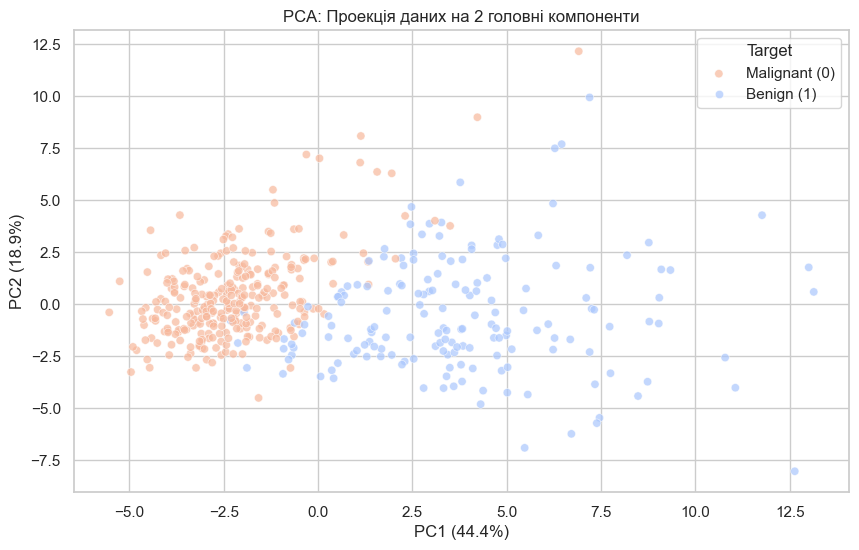

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette='coolwarm',
    alpha=0.7
)
plt.title('PCA: Проекція даних на 2 головні компоненти')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend(title='Target', labels=['Malignant (0)', 'Benign (1)']) # Перевірка відповідності міток
plt.show()

Зменшення розмірності до 2 компонент зберегло близько 63% дисперсії. Візуалізація показала, що навіть у 2D просторі класи є майже лінійно роздільними. Це підтверджує, що багато ознак у датасеті корелюють між собою (мультиколінеарність), і PCA ефективно прибирає цей шум, спрощуючи модель без значної втрати інформації.

## 6. Базова класифікація (sklearn)

In [46]:
# Логістична регресія з "коробки"
lr_base = LogisticRegression(random_state=42)
lr_base.fit(X_train_scaled, y_train)
y_pred_base = lr_base.predict(X_test_scaled)

f1_base = f1_score(y_test, y_pred_base)
print(f"Sklearn Logistic Regression F1-score: {f1_base:.4f}")

Sklearn Logistic Regression F1-score: 0.9861


## 7. Оптимізація Градієнтним спуском (PyTorch)
Реалізуємо логістичну регресію на PyTorch, щоб протестувати різні оптимізатори.

In [47]:
# Підготовка тензорів
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Модель логістичної регресії на PyTorch
class LogisticRegressionTorch(nn.Module):
    def __init__(self, n_features):
        super(LogisticRegressionTorch, self).__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Функція для тренування
def train_torch_model(optimizer_name, learning_rate=0.01, epochs=200):
    model = LogisticRegressionTorch(X_train.shape[1])
    criterion = nn.BCELoss() # Binary Cross Entropy

    # Вибір оптимізатора
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adadelta':
        optimizer = optim.Adadelta(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adagrad':
        optimizer = optim.Adagrad(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adamax':
        optimizer = optim.Adamax(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Nadam':
        optimizer = optim.NAdam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError("Unknown optimizer")

    # Цикл навчання
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Оцінка
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        predicted = (test_outputs >= 0.5).float()
        f1 = f1_score(y_test, predicted.numpy())

    return f1, predicted.numpy().flatten()

# Ручна реалізація Batch Gradient Descent
def batch_gradient_descent(X, y, lr=0.01, epochs=200):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        y_predicted = 1 / (1 + np.exp(-linear_model))

        # Градієнти
        dw = (1 / m) * np.dot(X.T, (y_predicted - y))
        db = (1 / m) * np.sum(y_predicted - y)

        weights -= lr * dw
        bias -= lr * db

    # Передбачення
    linear_pred = np.dot(X_test_scaled, weights) + bias
    y_pred_sigmoid = 1 / (1 + np.exp(-linear_pred))
    y_pred_cls = [1 if i > 0.5 else 0 for i in y_pred_sigmoid]

    return f1_score(y_test, y_pred_cls), y_pred_cls

# Запуск експериментів
optimizers_list = ['SGD', 'RMSprop', 'Adam', 'Adadelta', 'Adagrad', 'Adamax', 'Nadam']
results_gd = {}
predictions_gd = {}

# Ручний Batch GD
f1_batch, pred_batch = batch_gradient_descent(X_train_scaled, y_train)
results_gd['Batch GD (Manual)'] = f1_batch
predictions_gd['Batch GD (Manual)'] = pred_batch

# PyTorch Optimizers
for opt_name in optimizers_list:
    # Для Adadelta зазвичай потрібен більший LR
    lr = 1.0 if opt_name == 'Adadelta' else 0.01
    f1, pred = train_torch_model(opt_name, learning_rate=lr)
    results_gd[opt_name] = f1
    predictions_gd[opt_name] = pred

print("Результати F1-score для різних методів градієнтного спуску:")
for name, score in results_gd.items():
    print(f"{name}: {score:.4f}")

Результати F1-score для різних методів градієнтного спуску:
Batch GD (Manual): 0.9583
SGD: 0.9577
RMSprop: 0.9790
Adam: 0.9790
Adadelta: 0.9861
Adagrad: 0.9517
Adamax: 0.9793
Nadam: 0.9722


## 8. Оптимізація Генетичним алгоритмом (PyGAD)

In [48]:
# Функція пристосованості (Fitness Function)
# Генетичний алгоритм шукає ваги (w) та зміщення (b)
def fitness_func(ga_instance, solution, solution_idx):
    # Розпакування рішення: останнім елементом буде bias
    weights = solution[:-1]
    bias = solution[-1]

    # Логістична регресія: z = dot(x, w) + b
    z = np.dot(X_train_scaled, weights) + bias
    # Sigmoid
    predictions = 1 / (1 + np.exp(-z))
    # Threshold
    class_predictions = (predictions >= 0.5).astype(int)

    # Цільова метрика
    f1 = f1_score(y_train, class_predictions)
    return f1

# Налаштування параметрів GA
num_genes = X_train.shape[1] + 1 # 30 ваг + 1 bias

ga_instance = pygad.GA(num_generations=50,
                       num_parents_mating=5,
                       fitness_func=fitness_func,
                       sol_per_pop=20,
                       num_genes=num_genes,
                       mutation_percent_genes=10,
                       parent_selection_type="sss",
                       crossover_type="single_point",
                       mutation_type="random",
                       random_seed=42)

# Запуск
ga_instance.run()

# Отримання найкращого рішення
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Найкращий результат на тренувальній вибірці (GA): {solution_fitness:.4f}")

# Передбачення на тесті
best_weights = solution[:-1]
best_bias = solution[-1]
z_test = np.dot(X_test_scaled, best_weights) + best_bias
y_pred_ga_prob = 1 / (1 + np.exp(-z_test))
y_pred_ga = (y_pred_ga_prob >= 0.5).astype(int)

f1_ga = f1_score(y_test, y_pred_ga)
print(f"F1-score на тестовій вибірці (GA): {f1_ga:.4f}")

Найкращий результат на тренувальній вибірці (GA): 0.9913
F1-score на тестовій вибірці (GA): 0.9577


## 9. Оцінка та порівняння (Зведена таблиця)


--- Підсумкова таблиця результатів ---
             Model / Optimizer  F1 Score
0  Sklearn Logistic Regression  0.986111
6                     Adadelta  0.986111
8                       Adamax  0.979310
5                         Adam  0.979021
4                      RMSprop  0.979021
9                        Nadam  0.972222
2            Batch GD (Manual)  0.958333
1            Genetic Algorithm  0.957746
3                          SGD  0.957746
7                      Adagrad  0.951724


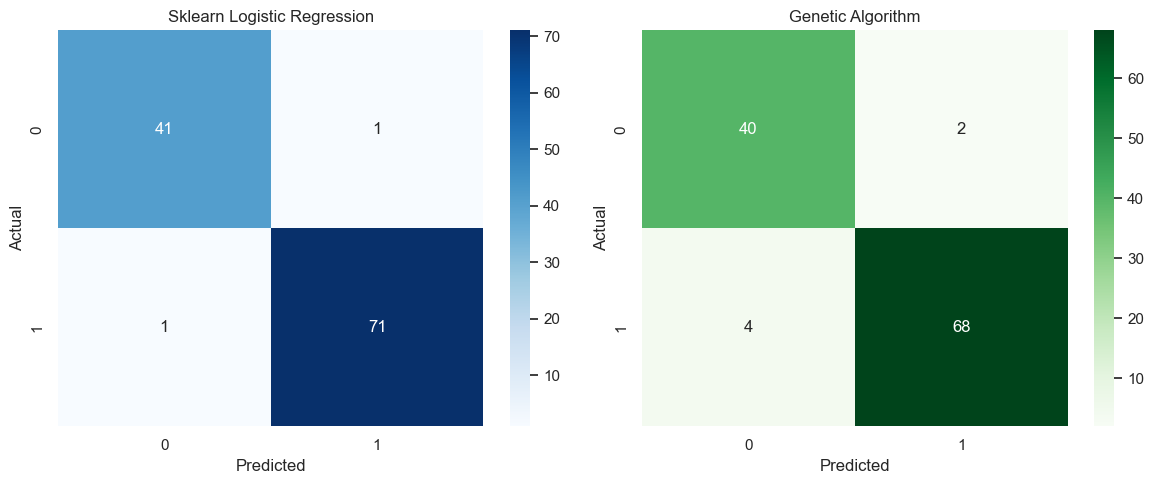

In [49]:
all_models = {
    'Sklearn Logistic Regression': f1_base,
    'Genetic Algorithm': f1_ga
}
all_models.update(results_gd)

results_df = pd.DataFrame(list(all_models.items()), columns=['Model / Optimizer', 'F1 Score'])
results_df = results_df.sort_values(by='F1 Score', ascending=False)

print("\n--- Підсумкова таблиця результатів ---")
print(results_df)

# Візуалізація матриць невідповідностей для найкращої та найгіршої моделі
# Беру Sklearn Base та GA

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sklearn
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Sklearn Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# GA
cm_ga = confusion_matrix(y_test, y_pred_ga)
sns.heatmap(cm_ga, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Genetic Algorithm')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 10. Висновки.

Для даної задачі найкращим вибором є Логістична регресія з оптимізатором Adadelta, хоча стабільними вважаються Adam або Nadam. Також підходить стандартна реалізація Sklearn. Використання PCA доцільне для візуалізації, але для максимальної точності краще використовувати повний набір стандартизованих ознак.

Генетичні алгоритми показав один з найнижчих результатів, та він краще підходять для задач, де простір пошуку складний, переривчастий або градієнт неможливо обчислити. Для задачі, як ця, GA є менш ефективним та повільнішим інструментом, оскільки він блукає "наосліп", замість того щоб рухатися чітко вниз по схилу, як градієнтний спуск.

Та на даному наборі даних, навіть найгірші результати не дають значної розбіжності, результати є принятними.